In [13]:
import pandas as pd

df = pd.read_csv('/content/cleaned_disease_dataset_2015landuse.csv')
df.head()

,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,missing_ratio
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206,0.0
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387,0.0
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856,0.0
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950,0.0
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649,0.0


## 특징 및 타겟 변수 분리

### Subtask:
데이터셋에서 'infection rate'를 타겟 변수로, 나머지를 특징 변수로 분리합니다.


In [14]:
y = df['infection_rate']
X = df.drop(columns=['year', 'country', 'admin', 'infection_rate'])

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of features (X):\n", X.head())
print("First 5 values of target (y):\n", y.head())

Shape of features (X): (473, 13)
Shape of target (y): (473,)
First 5 rows of features (X):
    max_temperature  min_temperature  avg_temperature  Buffa      Cattl  \
0        307.42114        297.76172        302.50760    0.0  25.000049   
1        304.47192        297.88160        300.27893    0.0  38.008688   
2        307.73170        299.50660        302.80447    0.0  17.566445   
3        307.41138        298.78003        302.61942    0.0  29.597071   
4        308.31274        297.82104        303.14368    0.0  28.843678   

        Chick  Ducks      Goats     Horse      Sheep      Swine  rate_landuse  \
0  164.065700    0.0  34.153420  0.693863  21.774243   9.682960      0.076206   
1   96.864817    0.0  12.506484  0.008877  12.373391   3.865450      0.074387   
2  303.908919    0.0  58.134766  0.019041  40.947445   6.821150      0.407856   
3  203.094681    0.0  69.010943  0.027864  45.871831  18.292361      0.143950   
4  138.295650    0.0  65.134086  0.079677  48.346972   4.8

## 결정 트리 모델 적용 및 학습

### Subtask:
분리된 특징과 타겟 변수를 사용하여 결정 트리 모델(회귀 또는 분류)을 학습시키고, 각 특징의 중요도를 분석하여 감염률에 미치는 영향을 파악합니다.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# 1. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# 2. Create a Decision Tree Regressor model instance
dt_regressor = DecisionTreeRegressor(random_state=42)

# 3. Train the model using the training data
dt_regressor.fit(X_train, y_train)

# 4. Extract and print feature importances
feature_importances = dt_regressor.feature_importances_
features = X.columns

importances_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances:\n", importances_df)


Shape of X_train: (378, 13)
Shape of X_test: (95, 13)
Shape of y_train: (378,)
Shape of y_test: (95,)

Feature Importances:
             Feature  Importance
1   min_temperature    0.457199
2   avg_temperature    0.158532
9             Sheep    0.135429
6             Ducks    0.080417
8             Horse    0.037166
7             Goats    0.036363
0   max_temperature    0.030157
4             Cattl    0.022565
10            Swine    0.018717
5             Chick    0.013220
11     rate_landuse    0.010235
3             Buffa    0.000000
12    missing_ratio    0.000000


## 클러스터링 적용

### Subtask:
특징 변수에 클러스터링 알고리즘(예: K-평균)을 적용하여 데이터 내에서 자연스러운 그룹을 식별합니다. 클러스터와 감염률 간의 관계를 탐색합니다.

### Reasoning:
클러스터링은 데이터 내의 숨겨진 패턴과 자연스러운 그룹을 발견하는 데 유용합니다. K-평균 클러스터링을 적용하기 전에 '엘보우(Elbow) 방법'을 사용하여 최적의 클러스터 개수(k)를 결정합니다. 이 방법은 다양한 k 값에 대해 클러스터 내 제곱합(Inertia)을 계산하고, 이 값이 급격히 줄어드는 '엘보우' 지점을 찾아 최적의 k로 설정합니다. 클러스터링 후, 각 클러스터에 속하는 데이터의 평균 감염률을 분석하여 클러스터가 감염률과 어떤 관계를 가지는지 파악합니다.

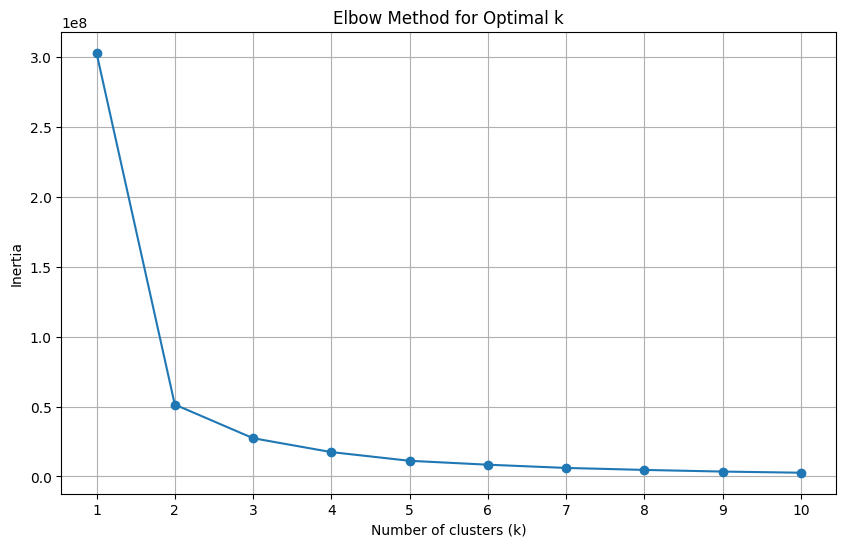


Optimal number of clusters (k) chosen based on Elbow method: 3

First 5 rows of DataFrame with new 'cluster' column:
    year       country              admin  infection_rate  max_temperature  \
0  2010  Burkina Faso  Boucle Du Mouhoun        0.585652        307.42114   
1  2010  Burkina Faso           Cascades        0.979432        304.47192   
2  2010  Burkina Faso             Centre        1.955671        307.73170   
3  2010  Burkina Faso         Centre-est        1.037736        307.41138   
4  2010  Burkina Faso        Centre-nord        0.379147        308.31274   

   min_temperature  avg_temperature  Buffa      Cattl       Chick  Ducks  \
0        297.76172        302.50760    0.0  25.000049  164.065700    0.0   
1        297.88160        300.27893    0.0  38.008688   96.864817    0.0   
2        299.50660        302.80447    0.0  17.566445  303.908919    0.0   
3        298.78003        302.61942    0.0  29.597071  203.094681    0.0   
4        297.82104        303.14368   

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Apply the Elbow method to determine an appropriate number of clusters (k)
# A list to store the inertia values for different k
inertia = []
k_range = range(1, 11) # Test k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 10 to suppress warning
    kmeans.fit(X) # X is the feature data prepared earlier
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Based on the plot, visually determine the 'elbow point'.
# Let's assume, for demonstration, the elbow is at k=3 or k=4.
# For this example, let's choose k=3 based on a typical elbow pattern.
# Users would interpret the plot and choose k accordingly.
optimal_k = 3

print(f"\nOptimal number of clusters (k) chosen based on Elbow method: {optimal_k}")

# 2. Instantiate a KMeans model with the chosen number of clusters
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# 3. Fit the KMeans model to the feature data (X)
kmeans_model.fit(X)

# 4. Add the generated cluster labels as a new column named 'cluster' to the original DataFrame df
df['cluster'] = kmeans_model.labels_

print("\nFirst 5 rows of DataFrame with new 'cluster' column:\n", df.head())

# 5. Calculate and print the mean 'infection_rate' for each cluster
mean_infection_rate_per_cluster = df.groupby('cluster')['infection_rate'].mean()

print("\nMean 'infection_rate' per cluster:\n", mean_infection_rate_per_cluster)

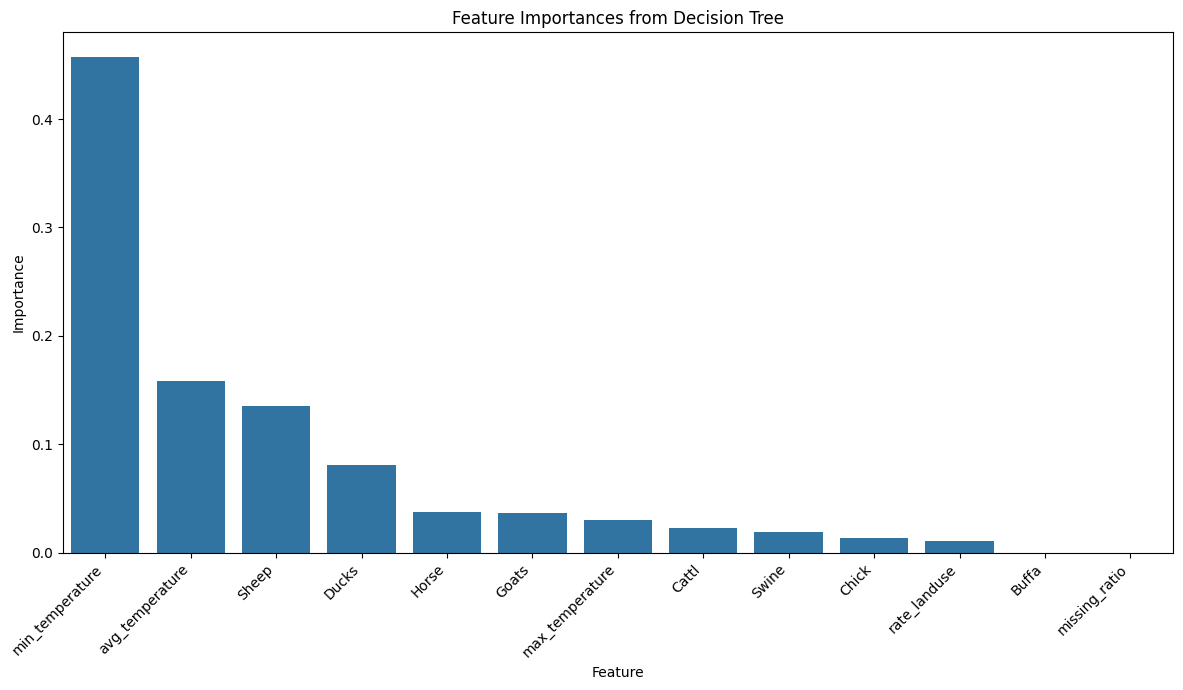

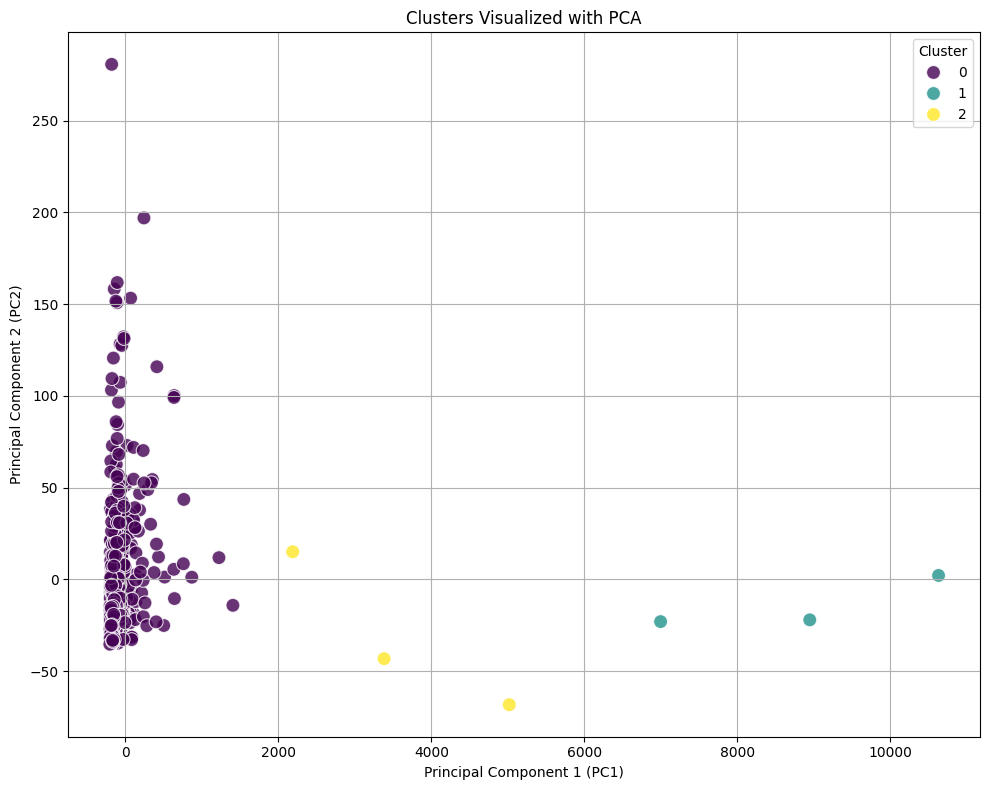

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

# 1. 시각화를 위한 라이브러리 임포트 (이미 임포트된 경우도 명시적으로)
# matplotlib.pyplot, seaborn은 이미 임포트되어 있을 가능성이 높지만, 명시적으로 포함합니다.

# 2. 결정 트리 모델에서 얻은 특징 중요도를 막대 그래프로 시각화
plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Importance', data=importances_df)
plt.title('Feature Importances from Decision Tree')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right') # x축 라벨 회전하여 가독성 높이기
plt.tight_layout() # 그래프 요소들이 겹치지 않도록 자동 조정
plt.show()

# 3. PCA를 사용하여 특징 데이터 X의 차원을 2D로 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) # X는 이전에 준비된 특징 데이터프레임

# 4. PCA 변환된 데이터를 DataFrame으로 만들고 'cluster' 열 추가
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster'] # df는 'cluster' 열이 추가된 원본 데이터프레임

# 5. 클러스터링 결과를 PCA를 사용하여 산점도로 시각화
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters Visualized with PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

## 회귀 모델 평가

### Subtask:
결정 트리 회귀 모델의 성능을 R-squared, MSE, MAE와 같은 적절한 회귀 평가 지표를 사용하여 평가합니다.

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Make predictions on the test set
y_pred = dt_regressor.predict(X_test)

# Calculate regression metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE

print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}") # Print RMSE
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared: 0.3822
Mean Squared Error (MSE): 23.3190
Root Mean Squared Error (RMSE): 4.8290
Mean Absolute Error (MAE): 2.6789


## 클러스터링 성능 평가

In [19]:
from sklearn.metrics import silhouette_score

# Ensure X is defined (re-run if kernel restarted or cell run out of order)
X = df.drop(columns=['year', 'country', 'admin', 'infection_rate'])

# Calculate Silhouette Score
silhouette_avg = silhouette_score(X, df['cluster'])

print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.9437


## 'infection_rate' 피처 추출

### Subtask:
데이터프레임에서 'infection_rate' 피처만을 추출하여 새로운 데이터셋을 준비합니다.


In [20]:
infection_rate_data = df['infection_rate']

print("First 5 values of 'infection_rate' data:")
print(infection_rate_data.head())

First 5 values of 'infection_rate' data:
0    0.585652
1    0.979432
2    1.955671
3    1.037736
4    0.379147
Name: infection_rate, dtype: float64


## 'infection_rate' 단일 피처 클러스터링

### Subtask:
추출된 'infection_rate' 피처에 K-평균 클러스터링을 적용합니다. 엘보우 방법을 사용하여 최적의 클러스터 개수를 결정하고, 클러스터링을 수행합니다.


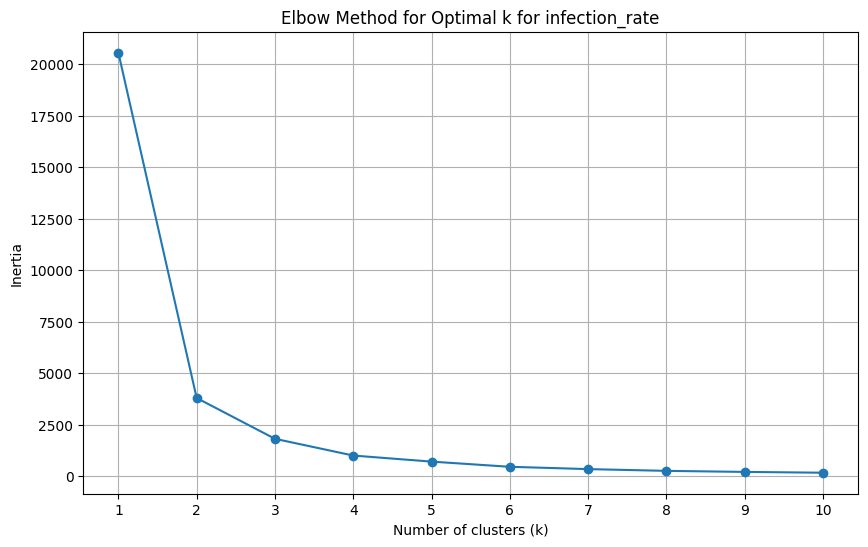


Optimal number of clusters (k) chosen for infection_rate based on Elbow method: 3

First 5 rows of DataFrame with new 'infection_rate_cluster' column:
   infection_rate  infection_rate_cluster
0        0.585652                       0
1        0.979432                       0
2        1.955671                       0
3        1.037736                       0
4        0.379147                       0

Mean 'infection_rate' per 'infection_rate_cluster':
 infection_rate_cluster
0     1.824517
2    10.363146
1    20.112435
Name: infection_rate, dtype: float64


In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Reshape infection_rate_data for KMeans (it expects a 2D array)
infection_rate_reshaped = infection_rate_data.values.reshape(-1, 1)

# 1. Apply the Elbow method to determine an appropriate number of clusters (k)
inertia_infection = []
k_range_infection = range(1, 11) # Test k from 1 to 10

for k in k_range_infection:
    kmeans_inf = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_inf.fit(infection_rate_reshaped)
    inertia_infection.append(kmeans_inf.inertia_)

# Plot the Elbow curve for infection_rate
plt.figure(figsize=(10, 6))
plt.plot(k_range_infection, inertia_infection, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k for infection_rate')
plt.xticks(k_range_infection)
plt.grid(True)
plt.show()

# Based on the plot, visually determine the 'elbow point'.
# Let's assume, for demonstration, the elbow is at k=3 for infection_rate.
optimal_k_infection = 3

print(f"\nOptimal number of clusters (k) chosen for infection_rate based on Elbow method: {optimal_k_infection}")

# 2. Instantiate a KMeans model with the chosen number of clusters for infection_rate
kmeans_infection_model = KMeans(n_clusters=optimal_k_infection, random_state=42, n_init=10)

# 3. Fit the KMeans model to the reshaped infection_rate data
kmeans_infection_model.fit(infection_rate_reshaped)

# 4. Add the generated cluster labels as a new column named 'infection_rate_cluster' to the original DataFrame df
df['infection_rate_cluster'] = kmeans_infection_model.labels_

print("\nFirst 5 rows of DataFrame with new 'infection_rate_cluster' column:")
print(df[['infection_rate', 'infection_rate_cluster']].head())

# 5. Calculate and print the mean 'infection_rate' for each new cluster
mean_infection_rate_per_single_feature_cluster = df.groupby('infection_rate_cluster')['infection_rate'].mean().sort_values()

print("\nMean 'infection_rate' per 'infection_rate_cluster':\n", mean_infection_rate_per_single_feature_cluster)

## 클러스터링 결과 시각화

### Subtask:
단일 피처에 대한 클러스터링 결과를 시각화합니다.


**Reasoning**:
To visualize the clustering results for the single 'infection_rate' feature, I will create a 1D scatter plot. I need to add jitter to the y-axis to prevent overlapping points and clearly show the cluster separation based on the 'infection_rate' values.



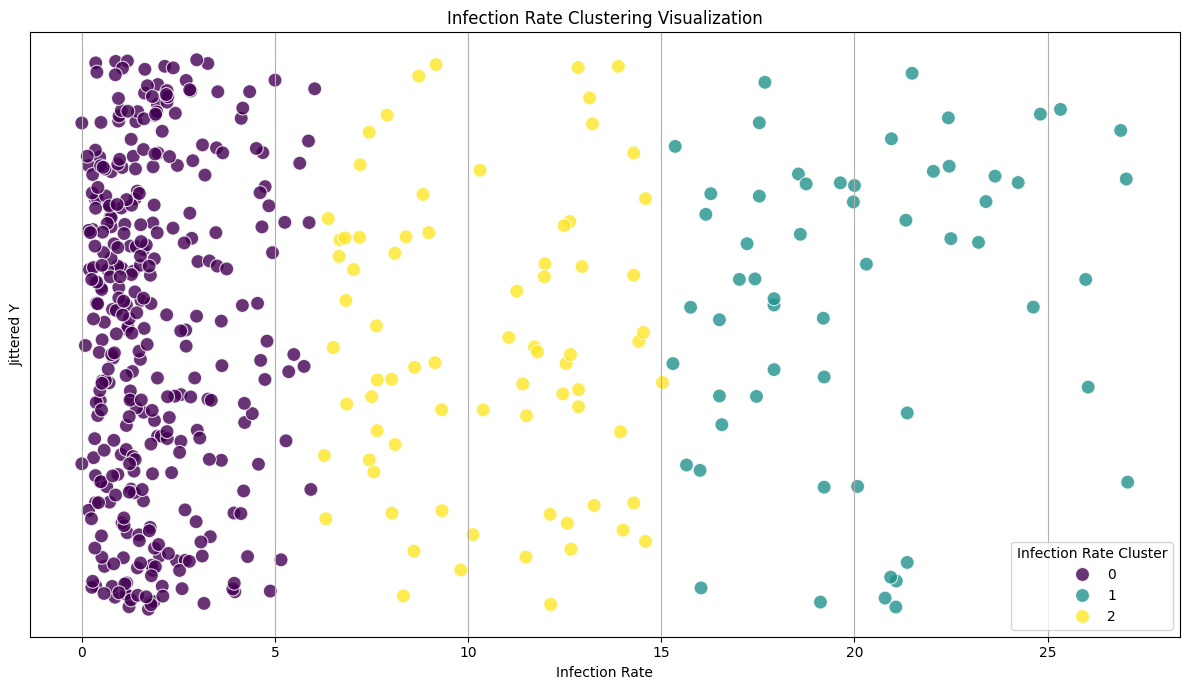

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Add jitter to the y-axis for better visualization of 1D data
# Create a dummy y-axis with random jitter for visualization
df['y_jitter'] = np.random.rand(len(df)) * 0.5 - 0.25  # Random values between -0.25 and 0.25

plt.figure(figsize=(12, 7))
sns.scatterplot(x='infection_rate', y='y_jitter', hue='infection_rate_cluster', data=df,
                palette='viridis', s=100, alpha=0.8, legend='full')

plt.title('Infection Rate Clustering Visualization')
plt.xlabel('Infection Rate')
plt.ylabel('Jittered Y')
plt.yticks([]) # Hide y-axis ticks as it's just for jitter
plt.grid(True, axis='x')
plt.legend(title='Infection Rate Cluster')
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import silhouette_score

# Ensure X is defined (re-run if kernel restarted or cell run out of order)
X = df.drop(columns=['year', 'country', 'admin', 'infection_rate'])

# Calculate Silhouette Score
silhouette_avg = silhouette_score(X, df['cluster'])

print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.9437
